# Preprocessing RSNA — MLO, grayscale 512×512, 1 immagine per paziente

Questo notebook prepara il dataset per il progetto:

- legge `dataset/train.csv`;
- usa solo immagini `MLO`;
- considera `cancer` come label;
- seleziona **un solo campione per paziente**;
- se un paziente è positivo, usa solo una sua immagine positiva e **non usa le sue immagini negative**;
- salva immagini preprocessate in `data/processed/`;
- mantiene il formato **grayscale 512×512**;
- crea CSV `train.csv`, `val.csv`, `test.csv`, `all_processed.csv` in `data/processed/metadata/`;
- salva plot, metriche di riepilogo ed ecotracker in `results/01_preprocessing/`.

La conversione a RGB per Stable Diffusion e per il classificatore (se necessario) verrà fatta successivamente, senza duplicare i file su disco.

In [27]:
from pathlib import Path
from datetime import datetime
import json
import shutil
import sys
import subprocess

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from tqdm import tqdm

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

try:
    import gdown
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    import gdown

In [28]:
# Configurazione iniziale + download dataset originale

PROJECT_NAME = "MammoDiffusion"

# Su Colab/Drive impostare ad esempio:
# PROJECT_ROOT_OVERRIDE = "/content/drive/MyDrive/MammoDiffusion"
PROJECT_ROOT_OVERRIDE = None


def find_project_root(project_name=PROJECT_NAME, override=PROJECT_ROOT_OVERRIDE):
    """Trova automaticamente la root del progetto MammoDiffusion."""
    if override is not None:
        root = Path(override).expanduser().resolve()
        if not root.exists():
            raise FileNotFoundError(f"PROJECT_ROOT_OVERRIDE non esiste: {root}")
        return root

    cwd = Path.cwd().resolve()

    for candidate in [cwd, *cwd.parents]:
        if candidate.name == project_name:
            return candidate
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    # ulteriore check in possibili cartelle
    for candidate in [
        cwd / project_name,
        Path("/content") / project_name,
        Path("/content/drive/MyDrive") / project_name,
        Path.home() / project_name,
        Path.home() / "Progetti" / project_name,
    ]:
        if candidate.exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Non riesco a trovare la root del progetto MammoDiffusion.\n"
        "Esegui il notebook dalla repo clonata oppure imposta PROJECT_ROOT_OVERRIDE."
    )


BASE_DIR = find_project_root()
NOTEBOOKS_DIR = BASE_DIR / "notebooks"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

try:
    from eco_tracker import measure_sustainability
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "codecarbon", "psutil"])
    from eco_tracker import measure_sustainability

DATASET_FILE_ID = "1fA-LXTcH-MF15ofZhGAM0osgM-SMfq2j"

ARCHIVE_PATH = (BASE_DIR / "data" / "original" / "dataset.rar").resolve()
EXTRACT_DIR  = (BASE_DIR / "data" / "original" / "_dataset_extract_tmp").resolve()
FINAL_DATASET_DIR = (BASE_DIR / "data" / "original" / "dataset").resolve()

DATASET_DIR = FINAL_DATASET_DIR

# True solo per riscaricare tutto da zero
FORCE_REDOWNLOAD_DATASET = False

# crea le cartelle necessarie se non esistono
ARCHIVE_PATH.parent.mkdir(parents=True, exist_ok=True)


def dataset_is_ready():
    """
    Controlla se il dataset è già stato estratto correttamente.
    Deve esistere train.csv e deve esserci almeno una PNG.
    """
    if not FINAL_DATASET_DIR.exists():
        return False

    if not (FINAL_DATASET_DIR / "train.csv").exists():
        return False

    png_count = (
        len(list(FINAL_DATASET_DIR.rglob("*.png"))) +
        len(list(FINAL_DATASET_DIR.rglob("*.PNG")))
    )

    return png_count > 0


def download_dataset():
    if FORCE_REDOWNLOAD_DATASET and ARCHIVE_PATH.exists():
        ARCHIVE_PATH.unlink()

    if ARCHIVE_PATH.exists():
        print(f"Archivio già presente: {ARCHIVE_PATH}")
        return

    print("Download dataset da Google Drive...")

    result = gdown.download(
        id=DATASET_FILE_ID,
        output=str(ARCHIVE_PATH),
        quiet=False
    )

    if result is None:
        raise RuntimeError(
            "gdown non è riuscito a scaricare il dataset. "
            "Controlla che il file Google Drive sia condiviso con "
            "'Chiunque abbia il link'."
        )

    if not ARCHIVE_PATH.exists():
        raise FileNotFoundError(f"Download fallito: non trovo {ARCHIVE_PATH}")

    # verifica che il file non sia vuoto
    if ARCHIVE_PATH.stat().st_size == 0:
        raise RuntimeError(f"Download fallito: file vuoto: {ARCHIVE_PATH}")

    print(f"Download completato: {ARCHIVE_PATH}")


def run_command(command):
    # esegue un comando catturando output ed errori e restituendoli come testo
    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    if result.returncode != 0:
        raise RuntimeError(
            "Comando fallito:\n"
            f"{' '.join(command)}\n\n"
            f"STDOUT:\n{result.stdout}\n\n"
            f"STDERR:\n{result.stderr}"
        )

    return result


def extract_rar_archive():
    if EXTRACT_DIR.exists():
        shutil.rmtree(EXTRACT_DIR)

    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    print("Estrazione dataset.rar...")

    # Metodo 1: patool, se trova un estrattore compatibile nel sistema.
    try:
        try:
            import patoolib
        except ImportError:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "patool"])
            import patoolib

        patoolib.extract_archive(
            str(ARCHIVE_PATH),
            outdir=str(EXTRACT_DIR)
        )

        print("Estrazione completata con patool.")
        return

    except Exception as e:
        print("patool non è riuscito a estrarre il .rar.")
        print("Errore:", e)

    # Possibili percorsi di 7-Zip su Windows
    possible_7zip_paths = [
        "7z",
        "7zz",
        r"C:\Program Files\7-Zip\7z.exe",
        r"C:\Program Files (x86)\7-Zip\7z.exe",
    ]

    commands_to_try = []

    for seven_zip_path in possible_7zip_paths:
        commands_to_try.append([
            seven_zip_path,
            "x",                                # estrae mantenendo la struttura delle cartelle
            str(ARCHIVE_PATH),                  # archivio da estrarre
            f"-o{EXTRACT_DIR}",                 # directory di destinazione
            "-y"                                # risponde automaticamente "si" alle richieste di sovrascrittura
        ])

    # Altri estrattori possibili
    commands_to_try.extend([
        ["unrar", "x", "-o+", str(ARCHIVE_PATH), str(EXTRACT_DIR)],
        ["tar", "-xf", str(ARCHIVE_PATH), "-C", str(EXTRACT_DIR)],
    ])

    last_errors = []

    for command in commands_to_try:
        try:
            run_command(command)
            print(f"Estrazione completata con: {command[0]}")
            return
        except Exception as e:
            last_errors.append(str(e))

    raise RuntimeError(
        "Non sono riuscito a estrarre dataset.rar.\n\n"
        "Soluzioni consigliate:\n"
        "1. Installa 7-Zip da https://www.7-zip.org/.\n"
        "2. Oppure converti dataset.rar in dataset.zip su Google Drive.\n"
        "3. Oppure, se sei su Colab/Linux, esegui prima: !apt-get install -y unrar\n\n"
        "Ultimo errore:\n"
        f"{last_errors[-1] if last_errors else 'Nessun errore disponibile'}"
    )


def normalize_extracted_dataset_folder():
    """
    Trova automaticamente train.csv dentro l'archivio estratto
    e porta la cartella corretta in BASE_DIR/dataset.
    """

    train_csv_candidates = list(EXTRACT_DIR.rglob("train.csv"))

    if len(train_csv_candidates) == 0:
        raise FileNotFoundError(
            f"Non ho trovato train.csv dentro l'archivio estratto: {EXTRACT_DIR}"
        )

    if len(train_csv_candidates) > 1:
        print("Attenzione: trovati più train.csv. Uso il primo:")
        for candidate in train_csv_candidates:
            print(candidate)

    source_csv = train_csv_candidates[0].resolve()
    source_dataset_dir = source_csv.parent.resolve()

    print("train.csv trovato in:")
    print(source_csv)

    print("Cartella dataset sorgente:")
    print(source_dataset_dir)

    if FINAL_DATASET_DIR.exists():
        shutil.rmtree(FINAL_DATASET_DIR)

    shutil.move(
        str(source_dataset_dir),
        str(FINAL_DATASET_DIR)
    )

    if EXTRACT_DIR.exists():
        shutil.rmtree(EXTRACT_DIR)

    final_csv = FINAL_DATASET_DIR / "train.csv"

    if not final_csv.exists():
        raise FileNotFoundError(f"train.csv non trovato dopo la normalizzazione: {final_csv}")

    png_count = (
        len(list(FINAL_DATASET_DIR.rglob("*.png"))) +
        len(list(FINAL_DATASET_DIR.rglob("*.PNG")))
    )

    if png_count == 0:
        raise FileNotFoundError(f"Nessuna immagine PNG trovata dentro: {FINAL_DATASET_DIR}")

    print("\nDataset pronto.")
    print("FINAL_DATASET_DIR:", FINAL_DATASET_DIR)
    print("train.csv:", final_csv)
    print("PNG trovate:", png_count)


if FORCE_REDOWNLOAD_DATASET:
    if FINAL_DATASET_DIR.exists():
        shutil.rmtree(FINAL_DATASET_DIR)

    if EXTRACT_DIR.exists():
        shutil.rmtree(EXTRACT_DIR)

if FORCE_REDOWNLOAD_DATASET or not dataset_is_ready():
    download_dataset()
    extract_rar_archive()
    normalize_extracted_dataset_folder()
else:
    print("Dataset già pronto, salto download ed estrazione.")
    print("DATASET_DIR:", DATASET_DIR)
    print("train.csv:", DATASET_DIR / "train.csv")

Dataset già pronto, salto download ed estrazione.
DATASET_DIR: /home/fede/Documenti/MammoDiffusion/data/original/dataset
train.csv: /home/fede/Documenti/MammoDiffusion/data/original/dataset/train.csv


In [29]:
# Configurazione preprocessing

CSV_PATH = DATASET_DIR / "train.csv"

OUTPUT_DIR = (BASE_DIR / "data" / "processed").resolve()

RESULTS_DIR = BASE_DIR / "results"
PREPROCESSING_RESULTS_DIR = RESULTS_DIR / "01_preprocessing"
PLOTS_DIR = PREPROCESSING_RESULTS_DIR / "plots"
METRICS_DIR = PREPROCESSING_RESULTS_DIR / "metrics"
ECOTRACKER_DIR = PREPROCESSING_RESULTS_DIR / "ecotracker"
PREPROCESSING_EVALUATION_PATH = METRICS_DIR / "preprocessing_evaluation.json"
PREPROCESSING_ECOTRACKER_PATH = ECOTRACKER_DIR / "preprocessing_ecotracker.json"

IMG_SIZE = 512
RANDOM_STATE = 42

VAL_SIZE = 0.15
TEST_SIZE = 0.15

VIEW_FILTER = "MLO"
IMAGE_EXTENSIONS = [".png", ".PNG"]

# Se True, cancella data/processed prima di ricrearla.
RESET_OUTPUT_DIR = False

print("BASE_DIR:", BASE_DIR)
print("DATASET_DIR:", DATASET_DIR)
print("CSV_PATH:", CSV_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("PREPROCESSING_RESULTS_DIR:", PREPROCESSING_RESULTS_DIR)

assert DATASET_DIR.exists(), f"Cartella dataset non trovata: {DATASET_DIR}"
assert CSV_PATH.exists(), f"CSV non trovato: {CSV_PATH}"

BASE_DIR: /home/fede/Documenti/MammoDiffusion
DATASET_DIR: /home/fede/Documenti/MammoDiffusion/data/original/dataset
CSV_PATH: /home/fede/Documenti/MammoDiffusion/data/original/dataset/train.csv
OUTPUT_DIR: /home/fede/Documenti/MammoDiffusion/data/processed
PREPROCESSING_RESULTS_DIR: /home/fede/Documenti/MammoDiffusion/results/01_preprocessing


In [30]:
# Helper condivisi per le visualizzazioni EDA
for directory in [PLOTS_DIR, METRICS_DIR, ECOTRACKER_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

EDA_SPLIT_ORDER = ["train", "val", "test"]
EDA_LABEL_ORDER = [0, 1]
EDA_LABEL_NAMES = {0: "negative", 1: "positive"}
EDA_LABEL_COLORS = {0: "#4c78a8", 1: "#e45756"}


def resolve_path(rel_or_abs, base=BASE_DIR):
    p = Path(rel_or_abs)
    return p if p.is_absolute() else base / p


def show_and_save_preprocessing_plot(fig, filename):
    output_path = PLOTS_DIR / filename
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"Salvato: {output_path}")
    plt.show()
    plt.close(fig)


def set_annotated_bar_ylim(ax, values, top_margin=0.15):
    values_array = np.asarray(values, dtype=float).ravel()
    y_max = float(values_array.max()) if values_array.size else 0.0
    ax.set_ylim(0, y_max * (1.0 + top_margin) if y_max > 0 else 1.0)


def annotate_bars(ax, bars, fmt="{:.0f}"):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            fmt.format(height),
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )


def read_grayscale_image_from_row(row):
    image_path = resolve_path(row["processed_path"])
    with Image.open(image_path) as img:
        return np.array(img.convert("L")), image_path


def get_split_dataframe_for_eda():
    required_cols = {"split", "label"}

    if "final_df" in globals() and required_cols.issubset(final_df.columns):
        return final_df.copy(), "final_df"

    csv_path = OUTPUT_DIR / "metadata" / "all_processed.csv"
    if not csv_path.is_file():
        print(f"EDA non eseguita: non trovo final_df né {csv_path}")
        return None, None

    df = pd.read_csv(csv_path).copy()
    missing_cols = required_cols.difference(df.columns)
    if missing_cols:
        print(f"EDA non eseguita: colonne mancanti in {csv_path}: {sorted(missing_cols)}")
        return None, None

    return df, str(csv_path)


def get_processed_dataframe_for_eda():
    required_cols = {"split", "label", "processed_path"}

    if "processed_df" in globals() and required_cols.issubset(processed_df.columns):
        return processed_df.copy(), "processed_df"

    if "processed_rows" in globals() and processed_rows:
        df = pd.DataFrame(processed_rows)
        if required_cols.issubset(df.columns):
            return df, "processed_rows"

    csv_path = OUTPUT_DIR / "metadata" / "all_processed.csv"
    if not csv_path.is_file():
        print(f"EDA non eseguita: metadata preprocessati non trovati: {csv_path}")
        return None, None

    df = pd.read_csv(csv_path).copy()
    missing_cols = required_cols.difference(df.columns)
    if missing_cols:
        print(f"EDA non eseguita: colonne mancanti in {csv_path}: {sorted(missing_cols)}")
        return None, None

    return df, str(csv_path)


def plot_class_distribution(neg_count, pos_count, title, filename,
                            count_unit="immagini", subtitle=None):
    """Bar chart negative vs positive con conteggio e percentuale annotati.
    neg_count/pos_count: interi gia' calcolati a monte (nessun ricalcolo qui).
    count_unit: 'immagini' o 'pazienti' - dichiarato sull'asse per chiarezza.
    """
    counts = {0: int(neg_count), 1: int(pos_count)}
    total = counts[0] + counts[1]
    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(
        [EDA_LABEL_NAMES[label] for label in EDA_LABEL_ORDER],
        [counts[label] for label in EDA_LABEL_ORDER],
        color=[EDA_LABEL_COLORS[label] for label in EDA_LABEL_ORDER],
    )
    set_annotated_bar_ylim(ax, [counts[label] for label in EDA_LABEL_ORDER])
    for bar, label in zip(bars, EDA_LABEL_ORDER):
        count = counts[label]
        pct = (count / total * 100) if total else 0.0
        ax.annotate(
            f"{count:,}\n({pct:.1f}%)".replace(",", "."),
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center", va="bottom", fontsize=11,
        )
    ax.set_title(title, fontsize=13, pad=24)
    if subtitle:
        ax.text(0.5, 1.005, subtitle, transform=ax.transAxes,
                ha="center", va="bottom", fontsize=9, color="#555555")
    ax.set_ylabel(f"Numero di {count_unit}")
    ax.grid(axis="y", alpha=0.25)
    show_and_save_preprocessing_plot(fig, filename)


def plot_negative_reduction_funnel(stage_labels, neg_values, pos_values,
                                   filename, count_unit="immagini"):
    """Grafico a cascata: mostra il crollo dei negativi attraverso le tappe,
    con i positivi affiancati per riferimento. Asse Y unico => il calo e' visibile."""
    x = np.arange(len(stage_labels))
    width = 0.38
    fig, ax = plt.subplots(figsize=(10, 5.5))
    neg_bars = ax.bar(x - width / 2, neg_values, width,
                      label="negative", color=EDA_LABEL_COLORS[0])
    pos_bars = ax.bar(x + width / 2, pos_values, width,
                      label="positive", color=EDA_LABEL_COLORS[1])
    set_annotated_bar_ylim(ax, list(neg_values) + list(pos_values))
    for bar in list(neg_bars) + list(pos_bars):
        height = bar.get_height()
        ax.annotate(
            f"{int(height):,}".replace(",", "."),
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3), textcoords="offset points",
            ha="center", va="bottom", fontsize=9,
        )
    ax.set_title("Riduzione progressiva del dataset: negativi vs positivi", fontsize=13)
    ax.set_ylabel(f"Numero di {count_unit}")
    ax.set_xticks(x)
    ax.set_xticklabels(stage_labels)
    ax.legend(title="Classe")
    ax.grid(axis="y", alpha=0.25)
    show_and_save_preprocessing_plot(fig, filename)

## 1. Caricamento CSV e controlli iniziali

In [31]:
df_all = pd.read_csv(CSV_PATH)

print("Shape CSV originale:", df_all.shape)
display(df_all.head())
print(df_all.columns.tolist())

Shape CSV originale: (54706, 14)


,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
0,2,10006,462822612,L,CC,61.0,0,0,0,NaN,0,NaN,29,False
1,2,10006,1459541791,L,MLO,61.0,0,0,0,NaN,0,NaN,29,False
2,2,10006,1864590858,R,MLO,61.0,0,0,0,NaN,0,NaN,29,False
3,2,10006,1874946579,R,CC,61.0,0,0,0,NaN,0,NaN,29,False
4,2,10011,220375232,L,CC,55.0,0,0,0,0.0,0,NaN,21,True


['site_id', 'patient_id', 'image_id', 'laterality', 'view', 'age', 'cancer', 'biopsy', 'invasive', 'BIRADS', 'implant', 'density', 'machine_id', 'difficult_negative_case']


In [32]:
required_cols = ["patient_id", "image_id", "laterality", "view", "cancer"]

# controlla se mancano colonne
missing_cols = [col for col in required_cols if col not in df_all.columns]
if missing_cols:
    raise ValueError(f"Errore, mancano alcune colonne obbligatorie: {missing_cols}")

df_all = df_all.copy()

df_all["patient_id"] = df_all["patient_id"].astype(str)
df_all["image_id"] = df_all["image_id"].astype(str)
df_all["view"] = df_all["view"].astype(str)
df_all["laterality"] = df_all["laterality"].astype(str)
df_all["cancer"] = df_all["cancer"].astype(int)

print("Distribuzione originale:")
print(df_all["cancer"].value_counts())

print("\nNumero pazienti originali:", df_all["patient_id"].nunique())
print("Pazienti positivi originali:", int(df_all.groupby("patient_id")["cancer"].max().sum()))

print("\nDistribuzione view:")
print(df_all["view"].value_counts())

Distribuzione originale:
cancer
0    53548
1     1158
Name: count, dtype: int64

Numero pazienti originali: 11913
Pazienti positivi originali: 486

Distribuzione view:
view
MLO    27903
CC     26765
AT        19
LM        10
ML         8
LMO        1
Name: count, dtype: int64


### EDA — Tappa 1: il dataset RSNA grezzo

Il dataset RSNA di partenza contiene tutte le proiezioni mammografiche. Il primo grafico mostra lo sbilanciamento estremo a livello di immagine: i casi positivi (cancro) sono una frazione minima del totale, situazione tipica dei dati di screening reali. Questo motiva l'intera strategia di selezione e bilanciamento.


Salvato: /home/fede/Documenti/MammoDiffusion/results/01_preprocessing/plots/dataset_full_distribution.png


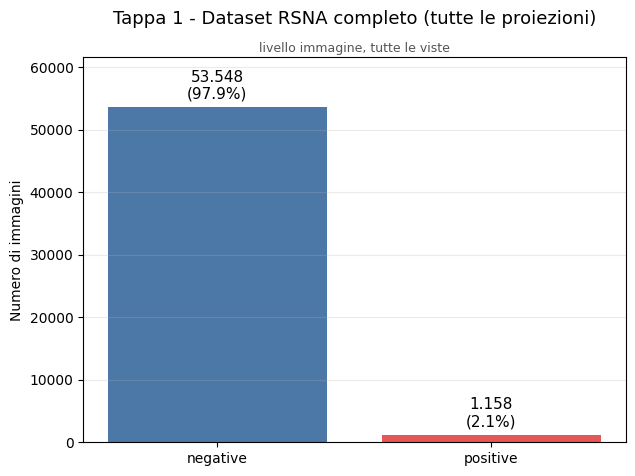

In [33]:
# EDA Tappa 1 - distribuzione del dataset RSNA completo (tutte le proiezioni)
# Conteggi a livello di IMMAGINE dal dataframe grezzo df_all
_neg_full = int((df_all["cancer"] == 0).sum())
_pos_full = int((df_all["cancer"] == 1).sum())

plot_class_distribution(
    neg_count=_neg_full,
    pos_count=_pos_full,
    title="Tappa 1 - Dataset RSNA completo (tutte le proiezioni)",
    subtitle="livello immagine, tutte le viste",
    count_unit="immagini",
    filename="dataset_full_distribution.png",
)

## 2. Indicizzazione immagini PNG

Le immagini sono sparse dentro `dataset/`, quindi qui creiamo una mappa `image_id → path`.

Il codice supporta nomi tipo:

- `image_id.png`
- `patient_id_image_id.png`
- altri nomi che contengono `image_id` come token separato da `_` o `-`.

In [34]:
# indicizzazine png

png_files = []
for ext in IMAGE_EXTENSIONS:
    png_files.extend(DATASET_DIR.rglob(f"*{ext}"))

# Rimuove duplicati mantenendo ordine
png_files = list(dict.fromkeys(png_files))

print("PNG trovate:", len(png_files))

png_count = (
        len(list(FINAL_DATASET_DIR.rglob("*.png"))) +
        len(list(FINAL_DATASET_DIR.rglob("*.PNG")))
    )

if len(png_files) == png_count:
    print("Non ci sono immagini duplicate")
else:
    print("Immagini duplicate:", png_count - len(png_files))
    
if len(png_files) == 0:
    raise FileNotFoundError(f"Nessuna immagine PNG trovata dentro {DATASET_DIR}")

# Mappa per stem esatto (nome del file senza estensione)
stem_map = {}
duplicate_stems = set()

for p in png_files:                               # p è un oggetto Path, percorso di ogni immagine
    stem = p.stem
    if stem in stem_map:
        duplicate_stems.add(stem)
    else:
        stem_map[stem] = p

# Mappa per token contenuti nel nome
# Un token viene utilizzato solo se identifica un unico file
token_map = {}
ambiguous_tokens = set()

for p in png_files:
    stem = p.stem
    tokens = stem.replace("-", "_").split("_") # splittiamo perchè potremmo avere image_id _ altro
    # nel csv potrebbero essere indicate anche solo con l'image_id
    tokens.append(stem)

    for token in tokens: # scorre ogni pezzo del nome file
        if token in token_map and token_map[token] != p: 
        # controllo se un token fosse già stato associato a un altro file
            ambiguous_tokens.add(token)
        else:
            token_map[token] = p

# I token associati a più file non possono essere usati per identificare in modo sicuro un'immagine
for token in ambiguous_tokens:
    token_map.pop(token, None) # rimozione token "ambigui", cioè che compaiono in più file diversi

print("Stem indicizzati:", len(stem_map))
print("Token univoci indicizzati:", len(token_map))
print("Stem duplicati rilevati, mantenendo il primo file:", len(duplicate_stems))
print("Token ambigui rimossi:", len(ambiguous_tokens))

PNG trovate: 54706
Non ci sono immagini duplicate
Stem indicizzati: 54706
Token univoci indicizzati: 109412
Stem duplicati rilevati, mantenendo il primo file: 0
Token ambigui rimossi: 11913


In [35]:
def find_image_path(patient_id, image_id):
    """
    Cerca l'immagine dentro DATASET_DIR.
    Supporta:
    - image_id.png
    - patient_id_image_id.png
    - file con image_id incluso nel nome
    """
    patient_id = str(patient_id)
    image_id = str(image_id)

    # Candidati diretti più probabili
    for ext in IMAGE_EXTENSIONS:
        candidates = [
            DATASET_DIR / f"{image_id}{ext}",
            DATASET_DIR / f"{patient_id}_{image_id}{ext}",
            DATASET_DIR / f"{image_id}_{patient_id}{ext}",
        ]

        for candidate in candidates:
            if candidate.exists():
                return candidate

    # Mappa su nome senza estensione
    exact_keys = [
        image_id,
        f"{patient_id}_{image_id}",
        f"{image_id}_{patient_id}",
    ]

    for key in exact_keys:
        if key in stem_map:
            return stem_map[key]

    # Fallback: image_id come token unico nel nome file
    if image_id in token_map:
        return token_map[image_id]

    return None

## 3. Filtro MLO e selezione corretta dei pazienti

Regola usata:

- paziente positivo = almeno una immagine con `cancer = 1`;
- paziente negativo = tutte le immagini con `cancer = 0`;
- per i pazienti positivi prendiamo solo immagini `MLO` con `cancer = 1`;
- per i pazienti negativi prendiamo immagini `MLO` con `cancer = 0`;
- evitiamo che un paziente positivo contribuisca anche come negativo, se presente.

In [36]:
# label dei pazienti

# raggruppa tutte le immagini per paziente e prende il max di cancro
patient_label_df = (
    df_all.groupby("patient_id", as_index=False)["cancer"]
    .max()
    .rename(columns={"cancer": "patient_label"})
)

# Unisce patient_label_df a df_all usando patient_id
df = df_all.merge(patient_label_df, on="patient_id", how="left")

# Manteniamo solo le immagini con la vista MLO
df_mlo = df[df["view"] == VIEW_FILTER].copy().reset_index(drop=True)

print("Immagini MLO:", len(df_mlo))
print("\nDistribuzione cancer nelle MLO:")
print(df_mlo["cancer"].value_counts())

print("\nPazienti nelle MLO:", df_mlo["patient_id"].nunique())
print("Pazienti positivi con almeno una MLO:", int(df_mlo.groupby("patient_id")["patient_label"].max().sum()))

Immagini MLO: 27903

Distribuzione cancer nelle MLO:
cancer
0    27313
1      590
Name: count, dtype: int64

Pazienti nelle MLO: 11913
Pazienti positivi con almeno una MLO: 486


In [37]:
# Positive: paziente positivo + immagine MLO positiva

positive_candidates = df_mlo[(df_mlo["cancer"] == 1)].copy().reset_index(drop=True)

# Negative: paziente realmente negativo, escludiamo le immagini negative appartenenti a pazienti positivi
# (se presenti)
negative_candidates = df_mlo[(df_mlo["patient_label"] == 0) & (df_mlo["cancer"] == 0)].copy().reset_index(drop=True)

print("Candidati positivi MLO:", len(positive_candidates))
print("Pazienti positivi con MLO positiva:", positive_candidates["patient_id"].nunique())

print("\nCandidati negativi MLO:", len(negative_candidates))
print("Pazienti negativi con MLO:", negative_candidates["patient_id"].nunique())

Candidati positivi MLO: 590
Pazienti positivi con MLO positiva: 486

Candidati negativi MLO: 26739
Pazienti negativi con MLO: 11427


### EDA — Tappa 2: dopo il filtro sulla vista MLO

Restringendo alle sole immagini in proiezione MLO (e considerando come negativi solo le immagini di pazienti realmente negativi), restano comunque molte migliaia di negativi a fronte di pochissimi positivi. Il divario resta enorme: è il motivo per cui, prima di costruire il dataset di lavoro, si applica un sottocampionamento dei negativi.

Salvato: /home/fede/Documenti/MammoDiffusion/results/01_preprocessing/plots/dataset_mlo_distribution.png


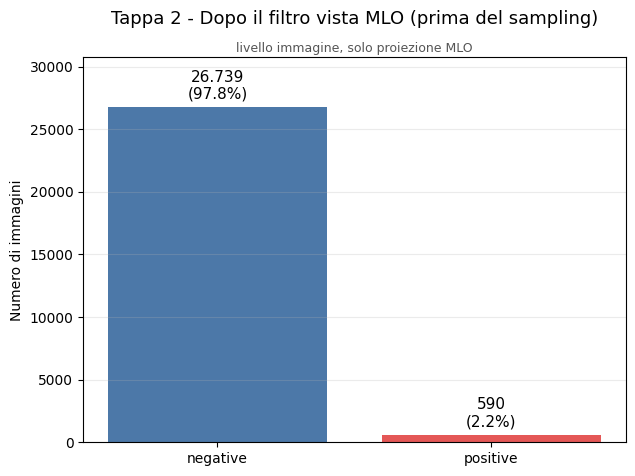

In [38]:
# EDA Tappa 2 - distribuzione dopo il filtro MLO, prima del sampling 1:5
# Conteggi a livello di immagine sui candidati MLO gia' calcolati nelle celle precedenti.
_neg_mlo = int(len(negative_candidates))
_pos_mlo = int(len(positive_candidates))

plot_class_distribution(
    neg_count=_neg_mlo,
    pos_count=_pos_mlo,
    title="Tappa 2 - Dopo il filtro vista MLO (prima del sampling)",
    subtitle="livello immagine, solo proiezione MLO",
    count_unit="immagini",
    filename="dataset_mlo_distribution.png",
)

## 4. Un solo campione per paziente

Usiamo una colonna random e `drop_duplicates("patient_id")`, così `patient_id` resta sicuramente una colonna.

In [39]:
def choose_one_per_patient(input_df, random_state=42):
    """
    Seleziona una sola riga per patient_id in modo riproducibile.
    Non usa groupby.apply, quindi evita problemi in cui patient_id diventa indice.
    """
    
    if "patient_id" not in input_df.columns:
        raise ValueError("La colonna patient_id non è presente nel dataframe di input.")

    rng = np.random.default_rng(random_state)

    out = input_df.copy().reset_index(drop=True)
    out["_random_choice"] = rng.random(len(out))

    out = (
        out.sort_values(["patient_id", "_random_choice"])
        .drop_duplicates(subset=["patient_id"], keep="first")
        .drop(columns=["_random_choice"])
        .reset_index(drop=True)
    )

    return out


# evitiamo che le sequenze di casuali siano le stesse, mantenendo la riproducibilità
positive_one = choose_one_per_patient(positive_candidates, random_state=RANDOM_STATE)
negative_one = choose_one_per_patient(negative_candidates, random_state=RANDOM_STATE + 1)

selected_df = pd.concat([positive_one, negative_one], ignore_index=True)
selected_df = selected_df.reset_index(drop=True)

# Label finale per il progetto
selected_df["label"] = selected_df["cancer"].astype(int)

print("Colonne selected_df:")
print(selected_df.columns.tolist())

print("\nDataset selezionato:", selected_df.shape)
print("\nDistribuzione label:")
print(selected_df["label"].value_counts())

print("\nPazienti unici:", selected_df["patient_id"].nunique())

assert "patient_id" in selected_df.columns, "Errore: patient_id non è una colonna."
assert selected_df["patient_id"].nunique() == len(selected_df), "Errore: ci sono più immagini per lo stesso paziente."
assert set(selected_df["label"].unique()).issubset({0, 1}), "Errore: label non binaria."

display(selected_df.head())

Colonne selected_df:
['site_id', 'patient_id', 'image_id', 'laterality', 'view', 'age', 'cancer', 'biopsy', 'invasive', 'BIRADS', 'implant', 'density', 'machine_id', 'difficult_negative_case', 'patient_label', 'label']

Dataset selezionato: (11913, 16)

Distribuzione label:
label
0    11427
1      486
Name: count, dtype: int64

Pazienti unici: 11913


,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case,patient_label,label
0,1,10130,1672636630,L,MLO,71.0,1,1,1,0.0,0,B,49,False,1,1
1,1,10226,461614796,L,MLO,71.0,1,1,1,0.0,0,C,49,False,1,1
2,1,1025,1803952236,L,MLO,56.0,1,1,0,0.0,0,B,49,False,1,1
3,2,10432,1434858530,L,MLO,65.0,1,1,1,NaN,0,NaN,48,False,1,1
4,1,10589,605115808,L,MLO,74.0,1,1,1,0.0,0,B,170,False,1,1


In [40]:
# Fissiamo un rate di negativi rispetto al numero di positivi

NEGATIVE_TO_POSITIVE_RATIO = 5

positive_df = selected_df[selected_df["label"] == 1].copy()
negative_df = selected_df[selected_df["label"] == 0].copy()

n_pos = len(positive_df)
n_neg_available = len(negative_df)

if n_pos == 0:
    raise ValueError("Non ci sono positivi in selected_df: impossibile fissare il rapporto negativi/positivi.")

if n_neg_available == 0:
    raise ValueError("Non ci sono negativi in selected_df: impossibile fissare il rapporto negativi/positivi.")

if NEGATIVE_TO_POSITIVE_RATIO is None:
    n_neg_target = n_neg_available
else:
    n_neg_target = int(n_pos * NEGATIVE_TO_POSITIVE_RATIO)

    if n_neg_target > n_neg_available:
        print(
            f"Attenzione: richiesti {n_neg_target} negativi, "
            f"ma disponibili solo {n_neg_available}. Verranno usati tutti i negativi disponibili."
        )
        n_neg_target = n_neg_available

negative_sampled_df = negative_df.sample(
    n=n_neg_target,
    random_state=RANDOM_STATE
).copy()

selected_df = pd.concat(
    [positive_df, negative_sampled_df],
    ignore_index=True
)

# Shuffle finale riproducibile
selected_df = selected_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

print("Dataset dopo definizione rapporto negativi/positivi:")
print(selected_df["label"].value_counts())

actual_n_pos = (selected_df["label"] == 1).sum()
actual_n_neg = (selected_df["label"] == 0).sum()

print(f"\nPositivi: {actual_n_pos}")
print(f"Negativi: {actual_n_neg}")
print(f"Rapporto negativi/positivi effettivo: {actual_n_neg / actual_n_pos:.2f}:1")

assert selected_df["patient_id"].nunique() == len(selected_df), "Errore: ci sono più immagini per lo stesso paziente."
assert selected_df["label"].isin([0, 1]).all(), "Errore: label non binaria."

Dataset dopo definizione rapporto negativi/positivi:
label
0    2430
1     486
Name: count, dtype: int64

Positivi: 486
Negativi: 2430
Rapporto negativi/positivi effettivo: 5.00:1


### EDA — Tappa 3: dataset finale bilanciato 1:5

Dopo aver tenuto una sola immagine per paziente e sottocampionato i negativi al rapporto 5:1 sui positivi, si ottiene il dataset di lavoro. Resta volutamente sbilanciato (circa 83%/17%): è proprio questo squilibrio residuo a motivare la generazione di immagini sintetiche nei notebook successivi. Il grafico a cascata riassume le tre tappe e rende visibile il crollo dei negativi su un asse comune.

Salvato: /home/fede/Documenti/MammoDiffusion/results/01_preprocessing/plots/dataset_sampled_distribution.png


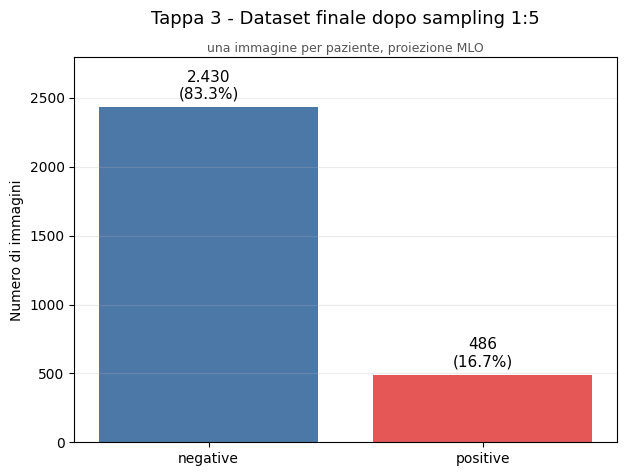

Salvato: /home/fede/Documenti/MammoDiffusion/results/01_preprocessing/plots/dataset_reduction_funnel.png


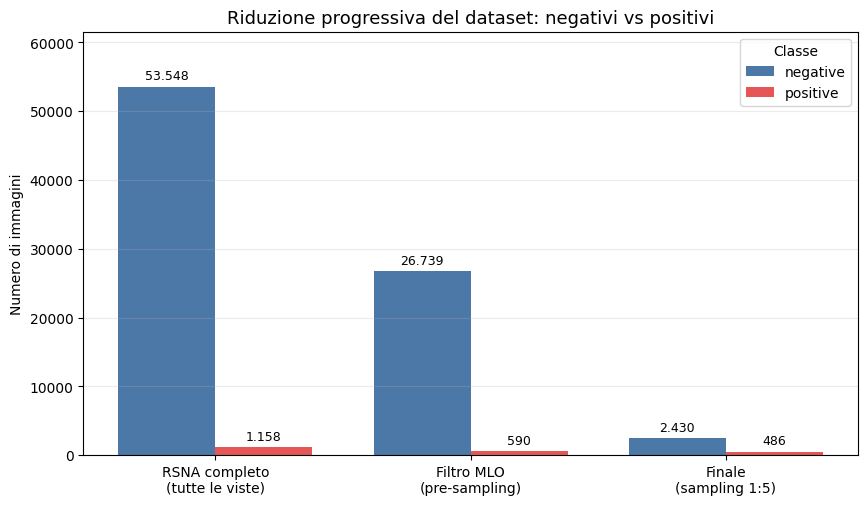

Riduzione negativi: 53548 -> 26739 -> 2430
Positivi per tappa: 1158 -> 590 -> 486


In [41]:
# EDA Tappa 3 - distribuzione del dataset finale dopo il sampling 1:5
# Conteggi a livello di immagine (= pazienti, perche' 1 immagine per paziente) su selected_df
_neg_final = int((selected_df["label"] == 0).sum())
_pos_final = int((selected_df["label"] == 1).sum())

plot_class_distribution(
    neg_count=_neg_final,
    pos_count=_pos_final,
    title="Tappa 3 - Dataset finale dopo sampling 1:5",
    subtitle="una immagine per paziente, proiezione MLO",
    count_unit="immagini",
    filename="dataset_sampled_distribution.png",
)

# Grafico a cascata riepilogativo delle tre tappe (negativi vs positivi, asse comune)
plot_negative_reduction_funnel(
    stage_labels=[
        "RSNA completo\n(tutte le viste)",
        "Filtro MLO\n(pre-sampling)",
        "Finale\n(sampling 1:5)",
    ],
    neg_values=[_neg_full, _neg_mlo, _neg_final],
    pos_values=[_pos_full, _pos_mlo, _pos_final],
    count_unit="immagini",
    filename="dataset_reduction_funnel.png",
)

print("Riduzione negativi:", _neg_full, "->", _neg_mlo, "->", _neg_final)
print("Positivi per tappa:", _pos_full, "->", _pos_mlo, "->", _pos_final)

## 5. Associazione dei path immagini

In [42]:
image_paths = []

# tqdm mostra barra di avanzamento, .iterarrows restituisce indice e contenuto della riga
for _, row in tqdm(selected_df.iterrows(), total=len(selected_df), desc="Ricerca immagini"):  
    path = find_image_path(
        patient_id=row["patient_id"],
        image_id=row["image_id"]
    )
    image_paths.append(path)

selected_df["image_path"] = image_paths

missing_df = selected_df[selected_df["image_path"].isna()].copy()

print("Immagini trovate:", selected_df["image_path"].notna().sum())
print("Immagini mancanti:", selected_df["image_path"].isna().sum())

if len(missing_df) > 0:
    print("\nEsempi immagini mancanti:")
    display(missing_df[["patient_id", "image_id", "view", "cancer"]].head(20))

Ricerca immagini: 100%|██████████| 2916/2916 [00:00<00:00, 23245.27it/s]

Immagini trovate: 2916
Immagini mancanti: 0


In [43]:
# Teniamo solo immagini realmente trovate

selected_df = selected_df[selected_df["image_path"].notna()].copy().reset_index(drop=True)
selected_df["image_path"] = selected_df["image_path"].astype(str)

print("Dataset dopo controllo file:", selected_df.shape)
print(selected_df["label"].value_counts())

assert selected_df["patient_id"].nunique() == len(selected_df), "Errore dopo path matching: più immagini per paziente."

Dataset dopo controllo file: (2916, 17)
label
0    2430
1     486
Name: count, dtype: int64


## 6. Split train / val / test

Dato che abbiamo già un solo campione per paziente, lo split può essere fatto sulle righe, ma resta stratificato per `label`.

In [44]:
def stratified_train_val_test_split(df, val_size=0.15, test_size=0.15, random_state=42):
    """
    Split train/val/test stratificato.
    Se la stratificazione non è possibile per pochi campioni, solleva un errore chiaro.
    """
    
    label_counts = df["label"].value_counts()
    if len(label_counts) < 2:
        raise ValueError("Serve almeno una classe positiva e una negativa per fare split stratificato.")

    if (label_counts < 2).any():
        raise ValueError(
            "Almeno una classe ha meno di 2 campioni. "
            "Impossibile fare split stratificato affidabile."
        )

    train_df, temp_df = train_test_split(
        df,
        test_size=val_size + test_size,
        stratify=df["label"],
        random_state=random_state
    )

    relative_test_size = test_size / (val_size + test_size)

    val_df, test_df = train_test_split(
        temp_df,
        test_size=relative_test_size,
        stratify=temp_df["label"],
        random_state=random_state
    )

    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    train_df["split"] = "train"
    val_df["split"] = "val"
    test_df["split"] = "test"

    final_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
    return final_df


final_df = stratified_train_val_test_split(
    selected_df,
    val_size=VAL_SIZE,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Distribuzione split/label:")
print(pd.crosstab(final_df["split"], final_df["label"]))

print("\nNumero righe final_df:", len(final_df))
print("Pazienti unici final_df:", final_df["patient_id"].nunique())

Distribuzione split/label:
label     0    1
split           
test    365   73
train  1701  340
val     364   73

Numero righe final_df: 2916
Pazienti unici final_df: 2916


### EDA: distribuzione degli split e delle classi

Questi grafici fotografano la composizione del dataset subito dopo lo split stratificato. Servono a rendere esplicito lo sbilanciamento tra classi e le proporzioni train/validation/test, cioè il motivo per cui nel notebook 02 viene introdotta una data augmentation mirata sui positivi.

Sorgente EDA split/classi: final_df


Salvato: /home/fede/Documenti/MammoDiffusion/results/01_preprocessing/plots/class_balance_per_split.png


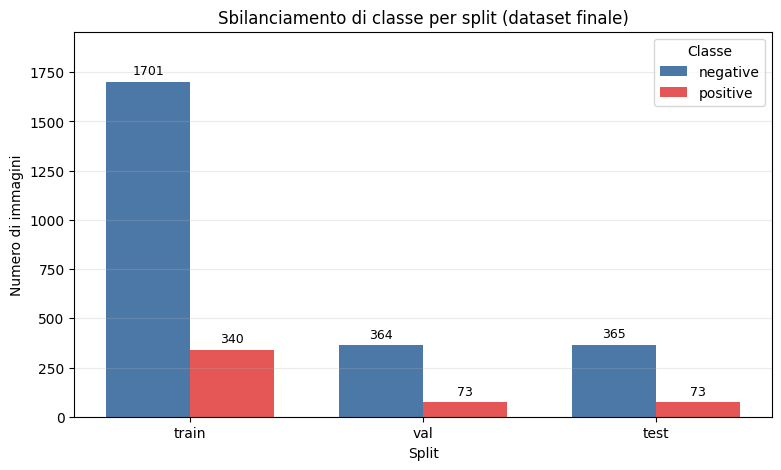

In [45]:
# EDA split/classi: sbilanciamento positive vs negative nei tre split (train/val/test)
# Sola lettura dei metadati gia' prodotti, nessun preprocessing ricalcolato.
eda_split_df, eda_split_source = get_split_dataframe_for_eda()

if eda_split_df is not None:
    eda_split_df["split"] = eda_split_df["split"].astype(str)
    eda_split_df["label"] = eda_split_df["label"].astype(int)
    print("Sorgente EDA split/classi:", eda_split_source)

    balance = (
        eda_split_df.groupby(["split", "label"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=EDA_SPLIT_ORDER, fill_value=0)
        .reindex(columns=EDA_LABEL_ORDER, fill_value=0)
    )

    x_positions = np.arange(len(EDA_SPLIT_ORDER))
    width = 0.36
    fig, ax = plt.subplots(figsize=(9, 5))
    negative_bars = ax.bar(
        x_positions - width / 2, balance[0].to_numpy(), width,
        label="negative", color=EDA_LABEL_COLORS[0],
    )
    positive_bars = ax.bar(
        x_positions + width / 2, balance[1].to_numpy(), width,
        label="positive", color=EDA_LABEL_COLORS[1],
    )
    set_annotated_bar_ylim(ax, balance.to_numpy())
    annotate_bars(ax, negative_bars)
    annotate_bars(ax, positive_bars)
    ax.set_title("Sbilanciamento di classe per split (dataset finale)")
    ax.set_xlabel("Split")
    ax.set_ylabel("Numero di immagini")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(EDA_SPLIT_ORDER)
    ax.legend(title="Classe")
    ax.grid(axis="y", alpha=0.25)
    show_and_save_preprocessing_plot(fig, "class_balance_per_split.png")

In [46]:
# Controllo anti-leakage
train_patients = set(final_df[final_df["split"] == "train"]["patient_id"])
val_patients = set(final_df[final_df["split"] == "val"]["patient_id"])
test_patients = set(final_df[final_df["split"] == "test"]["patient_id"])

assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

assert final_df["patient_id"].nunique() == len(final_df)

print("Nessun patient leakage. Un solo campione per paziente.")

Nessun patient leakage. Un solo campione per paziente.


## 7. Funzioni di preprocessing immagine

Output finale:

- PNG
- grayscale
- `mode = L`
- dimensione `512×512`

Il resize mantiene l'aspect ratio e aggiunge padding nero.

In [47]:
def load_as_grayscale_uint8(path):
    """
    Carica un'immagine e la restituisce come PIL grayscale 8-bit.

    Se l'immagine è 16-bit o ha valori molto ampi, applica una normalizzazione robusta
    usando i percentili 0.5 e 99.5 dei pixel non-zero.
    """
    img = Image.open(path)
    arr = np.array(img)

    # Caso RGB/RGBA: conversione PIL standard.
    if arr.ndim == 3:
        return img.convert("L")

    # Caso già uint8 (unsigned integer 8-bit)
    if arr.dtype == np.uint8:
        return Image.fromarray(arr, mode="L")

    # Caso 16-bit o altro: normalizzazione robusta.
    arr = arr.astype(np.float32)

    nonzero = arr[arr > 0]

    if len(nonzero) > 0:
        lo, hi = np.percentile(nonzero, [0.5, 99.5])
    else:
        lo, hi = arr.min(), arr.max()

    if hi <= lo:
        arr_norm = np.zeros_like(arr, dtype=np.uint8)
    else:
        arr = np.clip(arr, lo, hi)
        arr_norm = ((arr - lo) / (hi - lo) * 255.0).astype(np.uint8)

    return Image.fromarray(arr_norm, mode="L")


def resize_with_padding(img, size=512):
    """
    Resize mantenendo aspect ratio + padding nero.
    """
    img = img.copy()

    if img.size == (size, size):
        return img

    img.thumbnail((size, size), Image.Resampling.LANCZOS)

    canvas = Image.new("L", (size, size), color=0)

    left = (size - img.width) // 2
    top = (size - img.height) // 2

    canvas.paste(img, (left, top))

    return canvas


def preprocess_image(input_path, output_path, size=512):
    input_path = Path(input_path)
    output_path = Path(output_path)

    output_path.parent.mkdir(parents=True, exist_ok=True)

    img = load_as_grayscale_uint8(input_path)
    img = resize_with_padding(img, size=size)

    img.save(output_path)

## 8. Creazione output e preprocessing

Le immagini finali vengono salvate in `data/processed/<split>/<label>/`. La fase di preprocessing immagini è tracciata con EcoTracker e il JSON viene scritto in `results/01_preprocessing/ecotracker/preprocessing_ecotracker.json`.

In [48]:
if RESET_OUTPUT_DIR and OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

for split in ["train", "val", "test"]:
    for label in [0, 1]:
        (OUTPUT_DIR / split / str(label)).mkdir(parents=True, exist_ok=True)

(OUTPUT_DIR / "metadata").mkdir(parents=True, exist_ok=True)
for directory in [PLOTS_DIR, METRICS_DIR, ECOTRACKER_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Cartella output pronta:", OUTPUT_DIR)

Cartella output pronta: /home/fede/Documenti/MammoDiffusion/data/processed


In [49]:
def to_relative(path, base):
    """Path relativo a base se possibile, altrimenti solo il nome file."""
    path = Path(path).resolve()
    try:
        return str(path.relative_to(base))
    except ValueError:
        # path fuori da BASE_DIR (es. cartella temporanea di estrazione):
        # conserva un riferimento minimo non assoluto
        return path.name


processed_rows = []

with measure_sustainability(label="preprocessing_images", sample_interval=0.1) as eco_preprocessing:
    for _, row in tqdm(final_df.iterrows(), total=len(final_df), desc="Preprocessing immagini"):
        patient_id = str(row["patient_id"])
        image_id = str(row["image_id"])
        laterality = str(row["laterality"])
        view = str(row["view"])
        label = int(row["label"])
        split = str(row["split"])

        input_path = resolve_path(row["image_path"])

        filename = f"{patient_id}_{image_id}_{laterality}_{view}.png"
        output_path = OUTPUT_DIR / split / str(label) / filename

        try:
            preprocess_image(
                input_path=input_path,
                output_path=output_path,
                size=IMG_SIZE
            )

            processed_rows.append({
                "patient_id": patient_id,
                "image_id": image_id,
                "laterality": laterality,
                "view": view,
                "label": label,
                "cancer": int(row["cancer"]),
                "patient_label": int(row["patient_label"]),
                "split": split,
                "source": "real",
                "original_path": to_relative(input_path, BASE_DIR),
                "processed_path": to_relative(output_path, BASE_DIR),
            })

        except Exception as e:
            print(f"Errore con {input_path}: {e}")

Preprocessing immagini:   0%|          | 0/2916 [00:00<?, ?it/s]/tmp/ipykernel_42168/3870776022.py:17: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="L")
Preprocessing immagini: 100%|██████████| 2916/2916 [00:24<00:00, 121.06it/s]


## 9. Salvataggio CSV finali

I metadata finali vengono salvati in `data/processed/metadata/`. Dopo la normalizzazione visiva viene scritto anche il riepilogo di valutazione in `results/01_preprocessing/metrics/preprocessing_evaluation.json`.

In [50]:
processed_df = pd.DataFrame(processed_rows)

train_processed = processed_df[processed_df["split"] == "train"].reset_index(drop=True)
val_processed = processed_df[processed_df["split"] == "val"].reset_index(drop=True)
test_processed = processed_df[processed_df["split"] == "test"].reset_index(drop=True)

processed_df.to_csv(OUTPUT_DIR / "metadata" / "all_processed.csv", index=False)
train_processed.to_csv(OUTPUT_DIR / "metadata" / "train.csv", index=False)
val_processed.to_csv(OUTPUT_DIR / "metadata" / "val.csv", index=False)
test_processed.to_csv(OUTPUT_DIR / "metadata" / "test.csv", index=False)

if "eco_preprocessing" in globals() and getattr(eco_preprocessing, "metrics", None) is not None:
    preprocessing_eco_record = eco_preprocessing.metrics.to_dict()
    preprocessing_eco_record.update({
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "record_type": "preprocessing_images",
        "notebook": "01_Preprocessing_RSNA_512_gray_MLO",
        "output_dir": str(OUTPUT_DIR),
        "n_input_rows": int(len(final_df)),
        "n_processed_rows": int(len(processed_df)),
        "status": "completed",
    })
    with PREPROCESSING_ECOTRACKER_PATH.open("w", encoding="utf-8") as handle:
        json.dump(preprocessing_eco_record, handle, indent=2, ensure_ascii=False)
    print("EcoTracker JSON:", PREPROCESSING_ECOTRACKER_PATH)
else:
    print("EcoTracker preprocessing non disponibile: riesegui la cella di preprocessing immagini.")

print("Preprocessing completato.")
print("Totale:", len(processed_df))
print("Train:", len(train_processed))
print("Val:", len(val_processed))
print("Test:", len(test_processed))

print("\nDistribuzione label totale:")
print(processed_df["label"].value_counts())

print("\nDistribuzione split/label:")
print(pd.crosstab(processed_df["split"], processed_df["label"]))

display(processed_df.head())

EcoTracker JSON: /home/fede/Documenti/MammoDiffusion/results/01_preprocessing/ecotracker/preprocessing_ecotracker.json
Preprocessing completato.
Totale: 2916
Train: 2041
Val: 437
Test: 438

Distribuzione label totale:
label
0    2430
1     486
Name: count, dtype: int64

Distribuzione split/label:
label     0    1
split           
test    365   73
train  1701  340
val     364   73


,patient_id,image_id,laterality,view,label,cancer,patient_label,split,source,original_path,processed_path
0,8248,1228024526,L,MLO,1,1,1,train,real,data/original/dataset/8248_1228024526.png,data/processed/train/1/8248_1228024526_L_MLO.png
1,32984,1893902734,L,MLO,0,0,0,train,real,data/original/dataset/32984_1893902734.png,data/processed/train/0/32984_1893902734_L_MLO.png
2,37629,1196209769,R,MLO,0,0,0,train,real,data/original/dataset/37629_1196209769.png,data/processed/train/0/37629_1196209769_R_MLO.png
3,54728,189177296,R,MLO,0,0,0,train,real,data/original/dataset/54728_189177296.png,data/processed/train/0/54728_189177296_R_MLO.png
4,31287,1630385647,L,MLO,0,0,0,train,real,data/original/dataset/31287_1630385647.png,data/processed/train/0/31287_1630385647_L_MLO.png


## 10. Normalizzazione visiva (flip verso sinistra)

Dopo aver salvato i CSV, ogni immagine viene analizzata visivamente per verificare
che il tessuto mammario sia orientato verso **sinistra**.

- Se il tessuto è già a sinistra → nessuna modifica.
- Se il tessuto è a destra → l'immagine viene specchiata orizzontalmente e risalvata in-place.

La logica usa la **massa dei pixel non-neri** (foreground), non il metadato `laterality`,
rendendola più robusta a eventuali errori di annotazione nel dataset originale.

I CSV in `metadata/` vengono aggiornati con le nuove colonne:
`visual_side_before`, `visual_side_after`, `flipped_by_visual_rule`, `normalized_laterality`.

> **Nota**: `normalized_laterality` è fissata a `"L"` per convenzione di progetto;
> non è derivata dal metadato originale.

In [51]:
# Facciamo in modo che siano tutte rivolte verso lo stesso lato

TARGET_TISSUE_SIDE = "left"   # lascia così per "tutte verso L"

metadata_path = OUTPUT_DIR / "metadata" / "all_processed.csv"

if not metadata_path.exists():
    raise FileNotFoundError(f"File metadata non trovato: {metadata_path}")

processed_df = pd.read_csv(metadata_path)

required_cols = ["processed_path", "laterality", "split", "label"]

for col in required_cols:
    if col not in processed_df.columns:
        raise ValueError(f"Manca la colonna obbligatoria nel CSV: {col}")


def detect_tissue_side(image_path, min_threshold=5):
    """
    Rileva se il tessuto mammario è prevalentemente a sinistra o a destra.

    Usa la massa dei pixel non neri.
    È più robusto del solo metadata laterality.
    """
    with Image.open(image_path) as img:
        img = img.convert("L")
        arr = np.array(img)

    h, w = arr.shape

    # Maschera foreground: esclude il nero di sfondo.
    mask = arr > min_threshold

    foreground_pixels = mask.sum()

    if foreground_pixels == 0:
        return "unknown", 0.0, 0.0

    left_mass = mask[:, : w // 2].sum()
    right_mass = mask[:, w // 2 :].sum()

    total_mass = left_mass + right_mass

    left_ratio = left_mass / total_mass
    right_ratio = right_mass / total_mass

    if left_mass >= right_mass:
        return "left", left_ratio, right_ratio
    else:
        return "right", left_ratio, right_ratio


visual_side_before = []
visual_side_after = []
left_ratio_before = []
right_ratio_before = []
flipped_by_visual_rule = []

flipped_count = 0
kept_count = 0
unknown_count = 0

for idx, row in processed_df.iterrows():
    image_path = resolve_path(row["processed_path"])

    if not image_path.exists():
        raise FileNotFoundError(f"File non trovato: {image_path}")

    side_before, left_ratio, right_ratio = detect_tissue_side(image_path)

    visual_side_before.append(side_before)
    left_ratio_before.append(left_ratio)
    right_ratio_before.append(right_ratio)

    should_flip = (
        TARGET_TISSUE_SIDE == "left" and side_before == "right"
    ) or (
        TARGET_TISSUE_SIDE == "right" and side_before == "left"
    )

    if should_flip:
        with Image.open(image_path) as img:
            img = img.convert("L")
            img = ImageOps.mirror(img)
            img.save(image_path)

        flipped_count += 1
        flipped_by_visual_rule.append(True)

    elif side_before == "unknown":
        unknown_count += 1
        flipped_by_visual_rule.append(False)

    else:
        kept_count += 1
        flipped_by_visual_rule.append(False)

    side_after, _, _ = detect_tissue_side(image_path)
    visual_side_after.append(side_after)


processed_df["visual_side_before"] = visual_side_before
processed_df["visual_side_after"] = visual_side_after
processed_df["left_ratio_before"] = left_ratio_before
processed_df["right_ratio_before"] = right_ratio_before
processed_df["flipped_by_visual_rule"] = flipped_by_visual_rule
processed_df["normalized_tissue_side"] = TARGET_TISSUE_SIDE
#Tutte le immagini sono rivolte verso sinistra.
processed_df["normalized_laterality"] = "L"

# Risalva i CSV aggiornati con le nuove colonne di normalizzazione
train_processed = processed_df[processed_df["split"] == "train"].reset_index(drop=True)
val_processed = processed_df[processed_df["split"] == "val"].reset_index(drop=True)
test_processed = processed_df[processed_df["split"] == "test"].reset_index(drop=True)

processed_df.to_csv(OUTPUT_DIR / "metadata" / "all_processed.csv", index=False)
train_processed.to_csv(OUTPUT_DIR / "metadata" / "train.csv", index=False)
val_processed.to_csv(OUTPUT_DIR / "metadata" / "val.csv", index=False)
test_processed.to_csv(OUTPUT_DIR / "metadata" / "test.csv", index=False)

print("Normalizzazione visiva completata.")
print(f"Immagini specchiate perché avevano tessuto a destra: {flipped_count}")
print(f"Immagini già corrette: {kept_count}")
print(f"Immagini unknown: {unknown_count}")

print("\nPrima:")
print(pd.Series(visual_side_before).value_counts())

print("\nDopo:")
print(pd.Series(visual_side_after).value_counts())

assert (processed_df["visual_side_after"] != "right").all(), (
    "Errore: alcune immagini risultano ancora con tessuto a destra."
)

split_label_counts = (
    processed_df.groupby(["split", "label"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=EDA_SPLIT_ORDER, fill_value=0)
    .reindex(columns=EDA_LABEL_ORDER, fill_value=0)
)

preprocessing_evaluation = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "notebook": "01_Preprocessing_RSNA_512_gray_MLO",
    "dataset_dir": str(DATASET_DIR),
    "output_dir": str(OUTPUT_DIR),
    "plots_dir": str(PLOTS_DIR),
    "ecotracker_json": str(PREPROCESSING_ECOTRACKER_PATH),
    "img_size": IMG_SIZE,
    "view_filter": VIEW_FILTER,
    "n_rows": int(len(processed_df)),
    "n_patients": int(processed_df["patient_id"].nunique()),
    "label_counts": {
        str(int(label)): int(count)
        for label, count in processed_df["label"].value_counts().sort_index().items()
    },
    "split_label_counts": {
        str(split): {
            str(int(label)): int(split_label_counts.loc[split, label])
            for label in EDA_LABEL_ORDER
        }
        for split in EDA_SPLIT_ORDER
    },
    "visual_normalization": {
        "target_tissue_side": TARGET_TISSUE_SIDE,
        "flipped_count": int(flipped_count),
        "kept_count": int(kept_count),
        "unknown_count": int(unknown_count),
        "after_counts": {
            str(side): int(count)
            for side, count in pd.Series(visual_side_after).value_counts().items()
        },
    },
}

with PREPROCESSING_EVALUATION_PATH.open("w", encoding="utf-8") as handle:
    json.dump(preprocessing_evaluation, handle, indent=2, ensure_ascii=False)

print("Evaluation JSON:", PREPROCESSING_EVALUATION_PATH)

Normalizzazione visiva completata.
Immagini specchiate perché avevano tessuto a destra: 1462
Immagini già corrette: 1454
Immagini unknown: 0

Prima:
right    1462
left     1454
Name: count, dtype: int64

Dopo:
left    2916
Name: count, dtype: int64
Evaluation JSON: /home/fede/Documenti/MammoDiffusion/results/01_preprocessing/metrics/preprocessing_evaluation.json


### EDA: griglia di campioni preprocessati

Dopo la normalizzazione visiva, le immagini in `data/processed/` rappresentano la versione finale usata dai notebook successivi. La griglia mostra un campione riproducibile di positive e negative, utile per controllare orientamento, contrasto e presenza di artefatti macroscopici.

Sorgente EDA immagini: processed_df
Salvato: /home/fede/Documenti/MammoDiffusion/results/01_preprocessing/plots/sample_grid.png


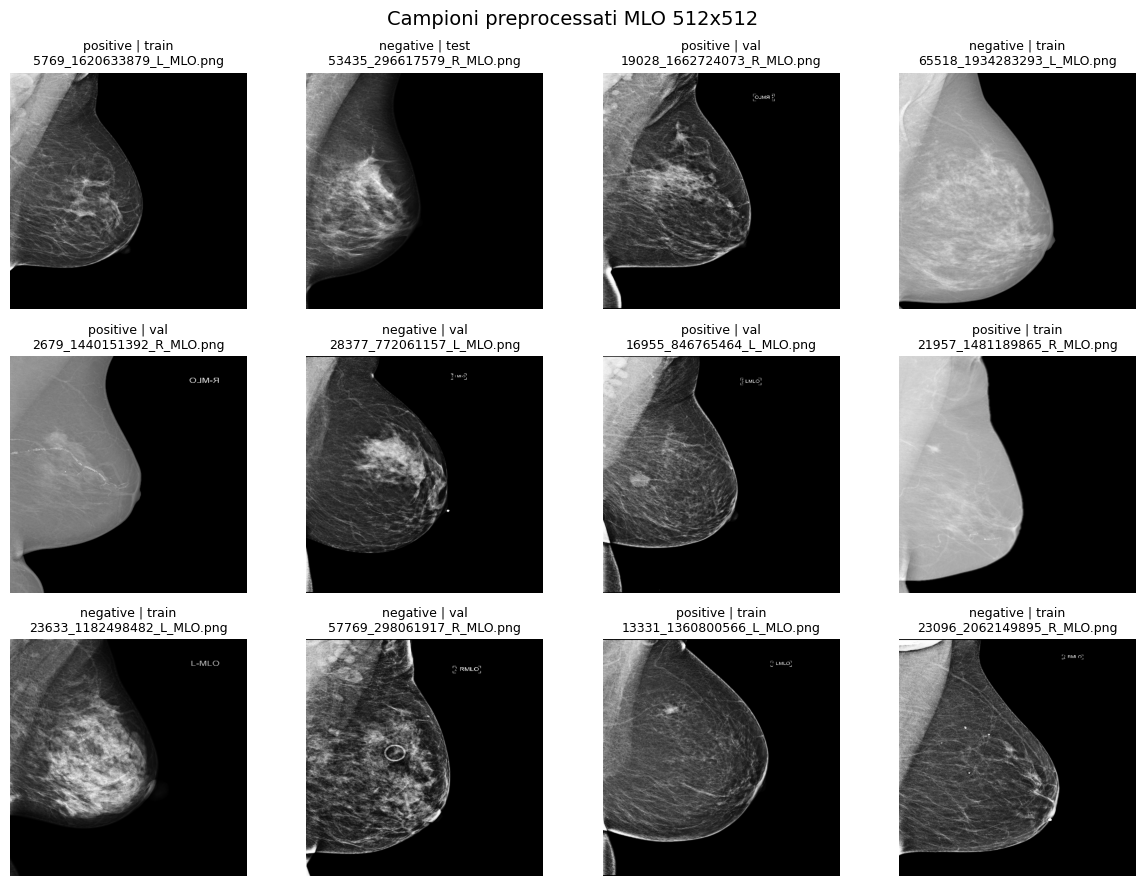

In [52]:
# EDA visiva: griglia campioni, sola lettura delle immagini preprocessate
eda_processed_df, eda_processed_source = get_processed_dataframe_for_eda()

if eda_processed_df is not None:
    eda_processed_df["split"] = eda_processed_df["split"].astype(str)
    eda_processed_df["label"] = eda_processed_df["label"].astype(int)
    print("Sorgente EDA immagini:", eda_processed_source)

    n_grid_images = 12
    n_per_label = n_grid_images // 2
    sampled_parts = []

    for label in EDA_LABEL_ORDER:
        subset = eda_processed_df[eda_processed_df["label"] == label]
        n_take = min(n_per_label, len(subset))
        if n_take > 0:
            sampled_parts.append(subset.sample(n=n_take, random_state=RANDOM_STATE + label))

    if sampled_parts:
        sample_grid_df = pd.concat(sampled_parts, axis=0)
        remaining = n_grid_images - len(sample_grid_df)
        if remaining > 0:
            remaining_pool = eda_processed_df.drop(index=sample_grid_df.index, errors="ignore")
            n_take = min(remaining, len(remaining_pool))
            if n_take > 0:
                sample_grid_df = pd.concat(
                    [
                        sample_grid_df,
                        remaining_pool.sample(n=n_take, random_state=RANDOM_STATE + 10),
                    ],
                    axis=0,
                )
        sample_grid_df = sample_grid_df.sample(frac=1, random_state=RANDOM_STATE + 20)

        valid_rows = []
        missing_images = 0
        for _, row in sample_grid_df.iterrows():
            image_path = resolve_path(row["processed_path"])
            if image_path.is_file():
                valid_rows.append(row)
            else:
                missing_images += 1

        if missing_images:
            print(f"Campioni esclusi dalla griglia perché mancanti: {missing_images}")

        if valid_rows:
            fig, axes = plt.subplots(3, 4, figsize=(12, 9))
            axes = axes.ravel()
            for ax, row in zip(axes, valid_rows):
                image_array, image_path = read_grayscale_image_from_row(row)
                ax.imshow(image_array, cmap="gray")
                ax.set_title(
                    f'{EDA_LABEL_NAMES[int(row["label"])]} | {row["split"]}\n{image_path.name}',
                    fontsize=9,
                )
                ax.axis("off")
            for ax in axes[len(valid_rows):]:
                ax.axis("off")
            fig.suptitle("Campioni preprocessati MLO 512x512", fontsize=14)
            fig.tight_layout()
            show_and_save_preprocessing_plot(fig, "sample_grid.png")
        else:
            print("Griglia campioni non generata: nessuna immagine valida trovata.")
    else:
        print("Griglia campioni non generata: CSV senza campioni disponibili.")